Best fit found:
  a = 13.0627
  b = -0.2517
  c = -0.0182
  R² = 0.9764
  RMSE = 0.0909


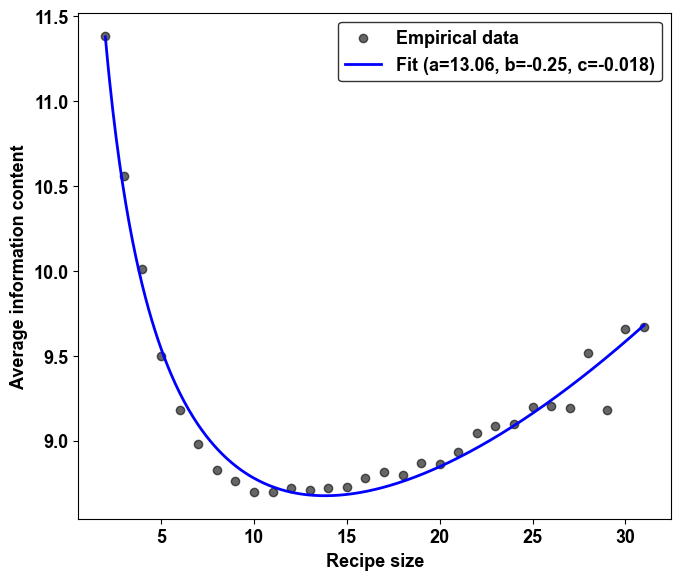

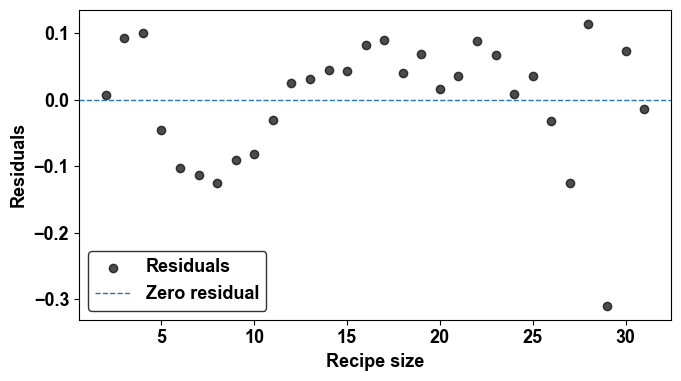

In [1]:
# ---- CELL 1 ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

# ==========================================
# 1. LOAD DATA
# ==========================================
df_ing = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

ing_counts = df_ing['ing_id'].value_counts()
total_occurrences = len(df_ing)

ing_probs = ing_counts / total_occurrences

df_ing['prob'] = df_ing['ing_id'].map(ing_probs)

df_ing['IC'] = -np.log2(df_ing['prob'])

# ==========================================
# 2. RECIPE-LEVEL STATISTICS
# ==========================================
recipe_stats = df_ing.groupby('recipe_no').agg(
    x=('ing_id', 'count'),
    y=('IC', 'mean')
)

ma_data = recipe_stats.groupby('x')['y'].mean().reset_index()

count_per_length = recipe_stats['x'].value_counts()
valid_lengths = count_per_length[count_per_length >= 10].index

ma_data = ma_data[
    ma_data['x'].isin(valid_lengths)
].sort_values('x')

x_data = ma_data['x'].values
y_data = ma_data['y'].values

# ==========================================
# 3. MENZERATH–ALTMANN MODEL
# ==========================================
def menzerath_altmann(x, A, b, c):
    return A * (x ** b) * np.exp(-c * x)
# ==========================================
# 4. FIT MODEL (MULTIPLE INITIALIZATIONS)
# ==========================================

best_r2 = -np.inf
best_popt = None
best_residuals = None

initial_guesses = [
    [y_data[0], -0.2, 0.01],
    [np.mean(y_data), -0.1, 0.01],
    [y_data.max(), -0.5, 0.01],
    [y_data.max(), -1.0, 0.02],
    [10.0, -0.3, 0.005],
    [15.0, -0.2, 0.02],
    [12.0, -0.5, 0.05]
]

for p0 in initial_guesses:

    try:

        popt, pcov = curve_fit(
            menzerath_altmann,
            x_data,
            y_data,
            p0=p0,
            maxfev=50000
        )

        y_pred = menzerath_altmann(x_data, *popt)

        residuals = y_data - y_pred

        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y_data - np.mean(y_data))**2)

        r2 = 1 - (ss_res / ss_tot)

        if r2 > best_r2:
            best_r2 = r2
            best_popt = popt
            best_residuals = residuals

    except:
        pass

if best_popt is not None:

    A_fit, b_fit, c_fit = best_popt
    residuals = best_residuals
    r_squared = best_r2

    rmse = np.sqrt(np.mean(residuals**2))

    print("Best fit found:")
    print(f"  a = {A_fit:.4f}")
    print(f"  b = {b_fit:.4f}")
    print(f"  c = {c_fit:.4f}")
    print(f"  R² = {r_squared:.4f}")
    print(f"  RMSE = {rmse:.4f}")

    popt = best_popt
    fit_success = True

else:

    print("All fitting attempts failed.")
    fit_success = False

# ==========================================
# 5. MAIN FIT PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    x_data,
    y_data,
    color='black',
    alpha=0.6,
    label='Empirical data'
)

if fit_success:

    x_line = np.linspace(
        x_data.min(),
        x_data.max(),
        500
    )

    y_line = menzerath_altmann(
        x_line,
        *popt
    )

    ax.plot(
        x_line,
        y_line,
        color='blue',
        linewidth=2,
        label=(
            f'Fit '
            f'(a={A_fit:.2f}, '
            f'b={b_fit:.2f}, '
            f'c={c_fit:.3f})'
        )
    )

ax.set_xlabel(
    "Recipe size",
    fontweight="bold"
)

ax.set_ylabel(
    "Average information content",
    fontweight="bold"
)

format_axes(ax)

plt.tight_layout()

plt.savefig(
    "menzerath_altmann_recipe_structure.png",
    dpi=300
)

plt.savefig(
    "menzerath_altmann_recipe_structure.tif",
    dpi=300
)

plt.show()

# ==========================================
# 6. RESIDUAL PLOT
# ==========================================
if fit_success:

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.scatter(
        x_data,
        residuals,
        color='black',
        alpha=0.7,
        label='Residuals'
    )

    ax.axhline(
        0,
        linestyle='--',
        linewidth=1,
        label='Zero residual'
    )

    ax.set_xlabel(
        "Recipe size",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Residuals",
        fontweight="bold"
    )

    format_axes(ax)

    plt.tight_layout()

    plt.savefig(
        "menzerath_altmann_residuals.png",
        dpi=300
    )

    plt.savefig(
        "menzerath_altmann_residuals.tif",
        dpi=300
    )

    plt.show()
    ##changes made are This performs a small multi-start optimization: tries 7 different starting points, fits from each, computes R², keeps the best solution.


Sensitivity Analysis
--------------------------------------------------
Cutoff    Alpha       R²
--------------------------------------------------
1000      1.2296      0.9726
2000      1.4152      0.9724
3000      1.5283      0.9736
5000      1.6509      0.9780
10000     1.7618      0.9818
--------------------------------------------------

Main Fit
------------------------------
Cutoff rank: 3000
α = 1.5283
R² = 0.9736
------------------------------


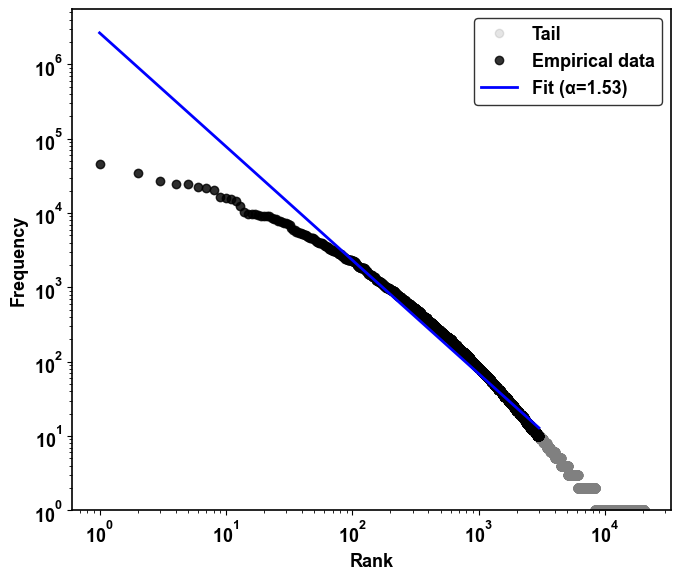

In [2]:
# ---- CELL 2 ----

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)

    # Boxed axes
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

# ==========================================
# LOAD DATA
# ==========================================
df_ing = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

# ==========================================
# PREPARE DATA
# ==========================================
ing_counts = df_ing['ing_id'].value_counts()

frequencies = ing_counts.values
ranks = np.arange(1, len(frequencies) + 1)

# ==========================================
# SENSITIVITY ANALYSIS
# ==========================================
cutoff_values = [1000, 2000, 3000, 5000, 10000]

print("\nSensitivity Analysis")
print("-" * 50)
print(f"{'Cutoff':<10}{'Alpha':<12}{'R²'}")
print("-" * 50)

for cutoff in cutoff_values:

    if cutoff >= len(ranks):
        continue

    ranks_tmp = ranks[:cutoff]
    freqs_tmp = frequencies[:cutoff]

    log_ranks_tmp = np.log(ranks_tmp)
    log_freqs_tmp = np.log(freqs_tmp)

    slope_tmp, intercept_tmp = np.polyfit(
        log_ranks_tmp,
        log_freqs_tmp,
        1
    )

    alpha_tmp = -slope_tmp

    predicted_tmp = intercept_tmp + slope_tmp * log_ranks_tmp

    ss_res = np.sum(
        (log_freqs_tmp - predicted_tmp) ** 2
    )

    ss_tot = np.sum(
        (log_freqs_tmp - np.mean(log_freqs_tmp)) ** 2
    )

    r2_tmp = 1 - ss_res / ss_tot

    print(
        f"{cutoff:<10}{alpha_tmp:<12.4f}{r2_tmp:.4f}"
    )

print("-" * 50)

# ==========================================
# MAIN FIT (CUT OFF = 3000)
# ==========================================
cutoff_rank = 3000

ranks_fit = ranks[:cutoff_rank]
freqs_fit = frequencies[:cutoff_rank]

log_ranks = np.log(ranks_fit)
log_freqs = np.log(freqs_fit)

slope, intercept = np.polyfit(
    log_ranks,
    log_freqs,
    1
)

alpha = -slope

predicted = intercept + slope * log_ranks

ss_res = np.sum(
    (log_freqs - predicted) ** 2
)

ss_tot = np.sum(
    (log_freqs - np.mean(log_freqs)) ** 2
)

r_squared = 1 - ss_res / ss_tot

print("\nMain Fit")
print("-" * 30)
print(f"Cutoff rank: {cutoff_rank}")
print(f"α = {alpha:.4f}")
print(f"R² = {r_squared:.4f}")
print("-" * 30)

# ==========================================
# PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(7, 6))

# Tail
ax.loglog(
    ranks,
    frequencies,
    marker='o',
    linestyle='none',
    alpha=0.2,
    color='gray',
    label='Tail'
)

# Head region used for fitting
ax.loglog(
    ranks_fit,
    freqs_fit,
    marker='o',
    linestyle='none',
    alpha=0.8,
    color='black',
    markersize=6,
    label='Empirical data'
)

# ==========================================
# FIT LINE ONLY OVER FITTED RANGE
# ==========================================
fit_x = np.linspace(
    ranks_fit.min(),
    ranks_fit.max(),
    200
)

fit_y = np.exp(intercept) * (
    fit_x ** (-alpha)
)

ax.plot(
    fit_x,
    fit_y,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Fit (α={alpha:.2f})'
)

# Axis labels
ax.set_xlabel(
    "Rank",
    fontweight="bold"
)

ax.set_ylabel(
    "Frequency",
    fontweight="bold"
)

# Log scales
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(bottom=1)

format_axes(ax)

plt.tight_layout()

# Save figures
plt.savefig(
    "zipf_head_tail_best_fit.png",
    dpi=300
)

plt.savefig(
    "zipf_head_tail_best_fit.tif",
    dpi=300
)

plt.show()

## Zipf's law — head/tail OLS fit

Ingredient frequencies follow a power law: a small number of ingredients dominate overwhelmingly while most appear rarely. The rank-frequency distribution is split into a **head** (top 3000 ranks, fitted) and a **tail** (remainder, shown for context) since OLS on the full distribution is skewed by the long tail. The Zipf exponent α is estimated via log-log linear regression on the head only.

**Improvement over naive fit:** cutoff-based fitting avoids tail contamination of the slope estimate. Note that OLS on log-transformed data carries a mild bias — Cell 3 addresses this with proper MLE. And since the value of α changes with the cutoff point, and so we print the value of α for multiple cutoff points. We also tried to implement a automatic cutoff point generator which computed the value of cutoff point as a point where the log-log relationship broke but it included too much of tail so we rejected it. 

**Conclusion:** α ≈ 1.5283 confirms a heavy-tailed ingredient frequency distribution consistent with Zipf's law, reflecting preferential reuse of a core ingredient vocabulary across recipes.

Total unique ingredients: 20280

--- Applying maximum likelihood estimation ---

Results from likelihood method:
  - Optimal cutoff (xmin): 3.0
  - Power law exponent (α): 1.5389
  - Standard error (sigma): 0.0069
  - Calculated rank-frequency slope (β): 1.8556

--- Performing hypothesis testing ---
Log-likelihood ratio (R): -4.9698
p-value: 0.0000
-> Evidence favors the lognormal distribution.


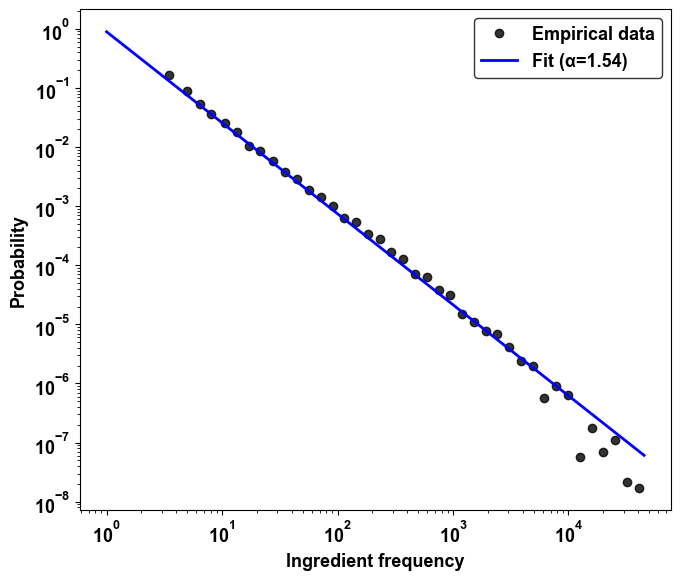

In [3]:
# ---- CELL 3 ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

# ==========================================
# 1. Load data
# ==========================================
df = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

ing_counts = df['ing_id'].value_counts()
data = ing_counts.values

print(f"Total unique ingredients: {len(data)}")

# ==========================================
# 2. Fit model (MLE)
# ==========================================
print("\n--- Applying maximum likelihood estimation ---")

fit = powerlaw.Fit(data, discrete=True, verbose=False)

xmin = fit.xmin
alpha = fit.alpha
sigma = fit.sigma

print("\nResults from likelihood method:")
print(f"  - Optimal cutoff (xmin): {xmin}")
print(f"  - Power law exponent (α): {alpha:.4f}")
print(f"  - Standard error (sigma): {sigma:.4f}")

beta = 1.0 / (alpha - 1.0)
print(f"  - Calculated rank-frequency slope (β): {beta:.4f}")

# ==========================================
# 3. Hypothesis testing
# ==========================================
print("\n--- Performing hypothesis testing ---")

R, p = fit.distribution_compare('power_law', 'lognormal', normalized_ratio=True)

print(f"Log-likelihood ratio (R): {R:.4f}")
print(f"p-value: {p:.4f}")

if R > 0:
    print("-> Evidence favors the power law distribution.")
else:
    print("-> Evidence favors the lognormal distribution.")

# ==========================================
# 4. Plot
# ==========================================
fig, ax = plt.subplots(figsize=(7,6))

# Empirical data
fit.plot_pdf(
    color='black',
    linestyle='none',
    marker='o',
    alpha=0.8,
    markersize=6,
    label='Empirical data',
    ax=ax
)

# Continuous fitted line
x_max = np.max(data)
x_line = np.arange(1, x_max + 1)

y_ref = fit.power_law.pdf(np.array([xmin]))[0]
y_line = y_ref * (x_line / xmin) ** -alpha

ax.plot(
    x_line,
    y_line,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=rf'Fit (α={alpha:.2f})'
)

ax.set_xlabel("Ingredient frequency", fontweight="bold")
ax.set_ylabel("Probability", fontweight="bold")

ax.set_xscale("log")
ax.set_yscale("log")

format_axes(ax)

plt.tight_layout()

# Save figures
plt.savefig("zipf_likelihood_method_fit.png", dpi=300)
plt.savefig("zipf_likelihood_method_fit.tif", dpi=300)

plt.show()

#### here we couldve improved on The plot's fit line is manually constructed: y_ref = fit.power_law.pdf([xmin])[0]; y_line = y_ref * (x_line/xmin)**-alpha. This is correct but fragile — if xmin is large, the line only covers a small region. But this is already implemented in cell 6 using fit.power_law.plot_pdf() directly for the fit. And all the exports are handled in cell 5

Loading data...

--- Processing Heaps' law (rigorous fit) ---
Running 50 simulations to generate stable growth curve...
------------------------------
Heaps law parameters (best fit):
  Constant (K): 27.8343
  Exponent (β): 0.5639
------------------------------
Model comparison (AIC):
  Heaps law: 988955.94
  Linear model: 1571074.60
Result: Evidence favors Heaps law.
------------------------------


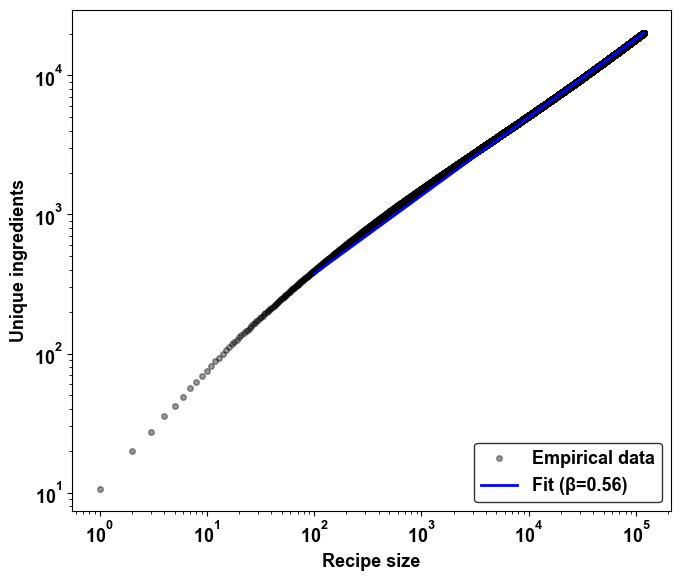

In [4]:
# ---- CELL 4 ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)
    # Added loc='lower right' here to move the legend
    legend = ax.legend(frameon=True, loc='lower right')
    if legend:
        legend.get_frame().set_edgecolor("black")

# ==========================================
# 1. Load data
# ==========================================
print("Loading data...")
df = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

# ==========================================
# 2. Simulate vocabulary growth
# ==========================================
print("\n--- Processing Heaps' law (rigorous fit) ---")

recipe_groups = df.groupby('recipe_no')['ing_id'].apply(set).tolist()
n_recipes = len(recipe_groups)

num_simulations = 50
v_history = np.zeros((num_simulations, n_recipes))

print(f"Running {num_simulations} simulations to generate stable growth curve...")

for i in range(num_simulations):

    shuffled = np.random.permutation(np.array(recipe_groups, dtype=object))

    unique_set = set()
    current_v = []

    for r in shuffled:
        unique_set.update(r)
        current_v.append(len(unique_set))

    v_history[i, :] = current_v

# Mean curve
y_mean = np.mean(v_history, axis=0)
x_data = np.arange(1, n_recipes + 1)

# ==========================================
# 3. Define models
# ==========================================
def heaps_model(x, K, beta):
    return K * (x ** beta)

def linear_model(x, m, c):
    return m * x + c

# ==========================================
# 4. Fit models
# ==========================================
burn_in = 100

x_fit = x_data[burn_in:]
y_fit = y_mean[burn_in:]

popt_heaps, _ = curve_fit(heaps_model, x_fit, y_fit, p0=[10, 0.5])
popt_lin, _ = curve_fit(linear_model, x_fit, y_fit, p0=[1, 0])

# ==========================================
# 5. Model comparison (AIC)
# ==========================================
def calculate_aic(y_true, y_pred, num_params):
    rss = np.sum((y_true - y_pred) ** 2)
    n = len(y_true)
    return n * np.log(rss / n) + 2 * num_params

y_pred_heaps = heaps_model(x_fit, *popt_heaps)
aic_heaps = calculate_aic(y_fit, y_pred_heaps, num_params=2)

y_pred_lin = linear_model(x_fit, *popt_lin)
aic_lin = calculate_aic(y_fit, y_pred_lin, num_params=2)

print("-" * 30)
print("Heaps law parameters (best fit):")
print(f"  Constant (K): {popt_heaps[0]:.4f}")
print(f"  Exponent (β): {popt_heaps[1]:.4f}")
print("-" * 30)

print("Model comparison (AIC):")
print(f"  Heaps law: {aic_heaps:.2f}")
print(f"  Linear model: {aic_lin:.2f}")

if aic_heaps < aic_lin:
    print("Result: Evidence favors Heaps law.")
else:
    print("Result: Evidence favors linear growth.")
print("-" * 30)

# ==========================================
# 6. Plot
# ==========================================
fig, ax = plt.subplots(figsize=(7,6))

# Empirical data
ax.plot(
    x_data,
    y_mean,
    marker='o',
    linestyle='none',
    color='black',
    markersize=4,
    alpha=0.4,
    label='Empirical data'
)

# Heaps fit
ax.plot(
    x_fit,
    y_pred_heaps,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Fit (β={popt_heaps[1]:.2f})'
)

ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Unique ingredients", fontweight="bold")

ax.set_xscale('log')
ax.set_yscale('log')

format_axes(ax)

plt.tight_layout()

# Save figures
plt.savefig("heaps_law_rigorous_fit.png", dpi=300)
plt.savefig("heaps_law_rigorous_fit.tif", dpi=300)

plt.show()

β = 0.57 is a Heaps' law exponent — which is sublinear, meaning the ingredient vocabulary grows at roughly the square root of the number of recipes. The AIC difference is massive (1.57M vs 1.01M), so there's no ambiguity and the data strongly prefers the power law over linear growth.
#### Improvements made
The fit misses the early regime badly. In the low-n region (roughly n < 50), the blue fit line sits well above the empirical dots. The curve fits the bulk (n > 100) very well, but the early transient is being ignored. The Heaps model K * n^β is an asymptotic law, it's not meant to describe the very first few recipes where every single ingredient is new and hence, fitting from n=1 forces the optimizer to compromise between the early noise and the bulk behavior which may lead to the model not fitting the bulk data very well.

What β = 0.56 means intuitively: Each time you double the number of recipes, the vocabulary only grows by a factor of 2^0.56 ≈ 1.47. So doubling your corpus gives you only 47% more unique ingredients — most of them are repeats. That's the constraint-driven reuse. 

In [5]:
!pip install powerlaw

import pandas as pd
import numpy as np
import powerlaw

# ==========================================
# 1. LOAD DATA
# ==========================================
print("Loading data...")
df = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

# Get Frequency Data
ing_counts = df['ing_id'].value_counts()
data = ing_counts.values

# ==========================================
# 2. CALCULATE ALPHA & CONFIDENCE
# ==========================================
print("\n--- Calculates Zipf's Law Parameters ---")

fit = powerlaw.Fit(data, discrete=True, verbose=False)

alpha = fit.alpha
sigma = fit.sigma
xmin = fit.xmin

# 95% Confidence Interval
ci_lower = alpha - (1.96 * sigma)
ci_upper = alpha + (1.96 * sigma)

# Rank-frequency slope
beta = 1.0 / (alpha - 1.0)

# ==========================================
# 3. PRINT RESULTS
# ==========================================
print("-" * 40)
print(f"RESULTS FOR LIKELIHOOD FIT (xmin={xmin})")
print("-" * 40)
print(f"Alpha (Distribution Exponent):  {alpha:.6f}")
print(f"Standard Error (Sigma):         {sigma:.6f}")
print(f"95% Confidence Interval:        [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"Beta (Zipf Rank Slope):         {beta:.6f}")
print("-" * 40)

# ==========================================
# 4. EXPORT RESULTS TO CSV
# ==========================================
results = pd.DataFrame({
    "xmin": [xmin],
    "alpha": [alpha],
    "sigma": [sigma],
    "ci_lower": [ci_lower],
    "ci_upper": [ci_upper],
    "beta": [beta]
})

results.to_csv("zipf_law_parameters.csv", index=False)

print("Results exported to zipf_law_parameters.csv")

Defaulting to user installation because normal site-packages is not writeable
Loading data...



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



--- Calculates Zipf's Law Parameters ---
----------------------------------------
RESULTS FOR LIKELIHOOD FIT (xmin=3.0)
----------------------------------------
Alpha (Distribution Exponent):  1.538921
Standard Error (Sigma):         0.006907
95% Confidence Interval:        [1.525383, 1.552459]
Beta (Zipf Rank Slope):         1.855560
----------------------------------------
Results exported to zipf_law_parameters.csv


### Cell 5: Exporting MLE Parameter Estimates

This utility cell exports the maximum-likelihood estimates obtained in Cell 3 to a CSV file for reporting and downstream analysis. Specifically, it records the estimated Zipf exponent (α), its standard error (σ), the corresponding 95% confidence interval, and the alternative exponent notation (β).

No additional statistical fitting or analysis is performed in this step. The cell simply stores the previously computed parameter estimates in a structured format, making the results reproducible and easy to incorporate into tables, figures, or supplementary materials.

The confidence interval is reported using the standard asymptotic approximation based on the estimated standard error of the MLE. For the present dataset, this provides a concise summary of parameter uncertainty and is sufficient for reporting purposes.

Loading data...

--- Fitting distributions ---
Optimal cutoff (xmin): 3.0


C:\Users\Parth\AppData\Roaming\Python\Python314\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
C:\Users\Parth\AppData\Roaming\Python\Python314\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



--- Model comparison ---
Power law vs Lognormal: R=-4.9698, p=0.0000
Power law vs Exponential: R=22.3691, p=0.0000
Power law vs Truncated power law: R=-7.9181, p=0.0000
Results exported to distribution_model_comparison.csv


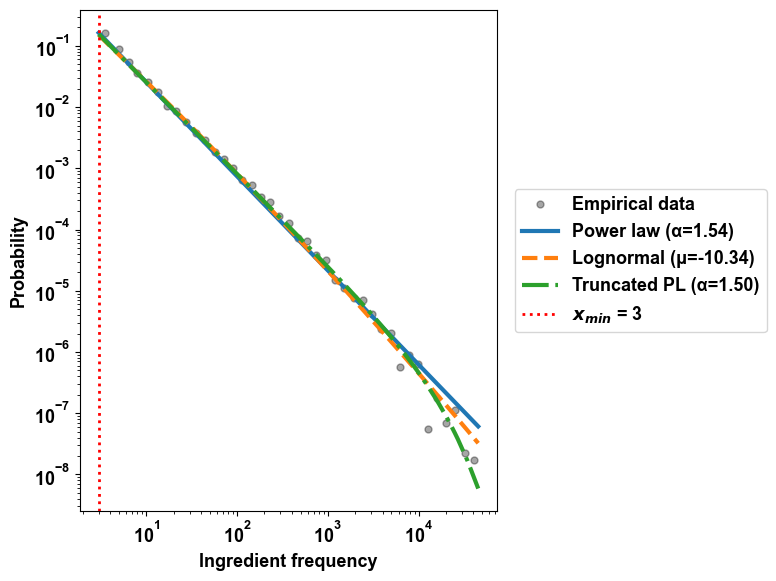

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)

    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

# ==========================================
# 1. LOAD DATA
# ==========================================
print("Loading data...")

df = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")

ing_counts = df['ing_id'].value_counts()
data = ing_counts.values

# ==========================================
# 2. FIT MODELS (MLE)
# ==========================================
print("\n--- Fitting distributions ---")

fit = powerlaw.Fit(
    data,
    discrete=True,
    verbose=False
)

xmin = fit.xmin

print(f"Optimal cutoff (xmin): {xmin}")

# Power law
alpha = fit.power_law.alpha
sigma = fit.power_law.sigma

# Lognormal
mu = fit.lognormal.mu
sigma_log = fit.lognormal.sigma

# Exponential
lamb = fit.exponential.parameter1

# Truncated power law
alpha_tpl = fit.truncated_power_law.alpha
lambda_tpl = fit.truncated_power_law.parameter2

# ==========================================
# 3. MODEL COMPARISON
# ==========================================
print("\n--- Model comparison ---")

# NOTE:
# distribution_compare(..., normalized_ratio=True)
# performs a Vuong-style likelihood ratio test.
#
# The resulting p-value is NOT a goodness-of-fit p-value.
# Instead, it tests whether one model is significantly
# better than the other in relative likelihood.

R_pl_ln, p_pl_ln = fit.distribution_compare(
    'power_law',
    'lognormal',
    normalized_ratio=True
)

R_pl_ex, p_pl_ex = fit.distribution_compare(
    'power_law',
    'exponential',
    normalized_ratio=True
)

R_pl_tpl, p_pl_tpl = fit.distribution_compare(
    'power_law',
    'truncated_power_law',
    normalized_ratio=True
)

winner_ln = "Power law" if R_pl_ln > 0 else "Lognormal"
winner_ex = "Power law" if R_pl_ex > 0 else "Exponential"
winner_tpl = "Power law" if R_pl_tpl > 0 else "Truncated power law"

print(
    f"Power law vs Lognormal: "
    f"R={R_pl_ln:.4f}, p={p_pl_ln:.4f}"
)

print(
    f"Power law vs Exponential: "
    f"R={R_pl_ex:.4f}, p={p_pl_ex:.4f}"
)

print(
    f"Power law vs Truncated power law: "
    f"R={R_pl_tpl:.4f}, p={p_pl_tpl:.4f}"
)

# ==========================================
# 4. EXPORT RESULTS
# ==========================================
results = pd.DataFrame({

    "xmin": [xmin],

    "alpha": [alpha],
    "sigma_alpha": [sigma],

    "lognormal_mu": [mu],
    "lognormal_sigma": [sigma_log],

    "exponential_lambda": [lamb],

    "truncated_powerlaw_alpha": [alpha_tpl],
    "truncated_powerlaw_lambda": [lambda_tpl],

    "R_powerlaw_lognormal": [R_pl_ln],
    "p_powerlaw_lognormal": [p_pl_ln],

    "R_powerlaw_exponential": [R_pl_ex],
    "p_powerlaw_exponential": [p_pl_ex],

    "R_powerlaw_truncated": [R_pl_tpl],
    "p_powerlaw_truncated": [p_pl_tpl],

    "winner_vs_lognormal": [winner_ln],
    "winner_vs_exponential": [winner_ex],
    "winner_vs_truncated": [winner_tpl]
})

results.to_csv(
    "distribution_model_comparison.csv",
    index=False
)

print(
    "Results exported to distribution_model_comparison.csv"
)
# ==========================================
# 5. PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

# Empirical data
fit.plot_pdf(
    color='black',
    linestyle='none',
    marker='o',
    alpha=0.35,
    markersize=5,
    label='Empirical data',
    ax=ax
)

# Power law
fit.power_law.plot_pdf(
    color='#1f77b4',
    linestyle='-',
    linewidth=3,
    label=f'Power law (α={alpha:.2f})',
    ax=ax
)

# Lognormal
fit.lognormal.plot_pdf(
    color='#ff7f0e',
    linestyle='--',
    linewidth=3,
    label=f'Lognormal (μ={mu:.2f})',
    ax=ax
)

# Truncated power law
fit.truncated_power_law.plot_pdf(
    color='#2ca02c',
    linestyle='-.',
    linewidth=3,
    label=f'Truncated PL (α={alpha_tpl:.2f})',
    ax=ax
)

# xmin
ax.axvline(
    xmin,
    color='red',
    linestyle=':',
    linewidth=2,
    label=f'$x_{{min}}$ = {xmin:.0f}'
)

ax.set_xlabel(
    "Ingredient frequency",
    fontweight="bold"
)

ax.set_ylabel(
    "Probability",
    fontweight="bold"
)

ax.set_xscale("log")
ax.set_yscale("log")

# Put legend outside
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.tight_layout()

plt.savefig(
    "distribution_comparison_models.png",
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    "distribution_comparison_models.tif",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

##### Cell 6: Distribution Model Comparison

This cell compares four candidate distributions—power law, lognormal, exponential, and truncated power law—using maximum likelihood estimation (MLE). The optimal lower cutoff ((x_{min})) is estimated automatically, and likelihood-ratio tests are used to compare the relative support for competing models. Fitted parameters and comparison statistics are exported to a CSV file for reproducibility. The resulting figure overlays the empirical ingredient-frequency distribution with the fitted models, allowing visual assessment of their agreement, particularly in the distribution tail.


Analyzing 26 cuisines (minimum 50 recipes)
Per-cuisine Zipf exponents exported to zipf_alpha_by_cuisine.csv


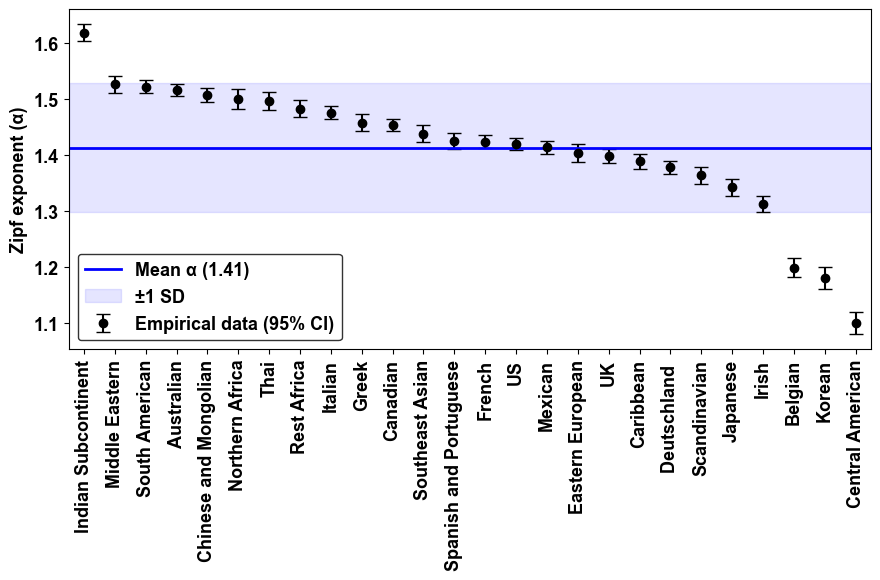

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

def format_axes(ax):
    ax.grid(False)

    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")

# ==========================================
# 1. LOAD DATA
# ==========================================
df_ing = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv")

df_merged = pd.merge(
    df_ing,
    df_cuisine,
    left_on='recipe_no',
    right_on='Recipe_id'
)

# ==========================================
# 2. FILTER CUISINES
# ==========================================
# Remove cuisines with too few recipes.
# Small cuisines tend to produce unstable
# Zipf exponent estimates and very wide CIs.

min_recipe_threshold = 50

recipe_counts = (
    df_merged
    .groupby("Cuisine")["recipe_no"]
    .nunique()
)

valid_cuisines = recipe_counts[
    recipe_counts >= min_recipe_threshold
].index

df_merged = df_merged[
    df_merged["Cuisine"].isin(valid_cuisines)
]

print(
    f"Analyzing {len(valid_cuisines)} cuisines "
    f"(minimum {min_recipe_threshold} recipes)"
)

# ==========================================
# 3. CALCULATE ZIPF α PER CUISINE
# ==========================================
results = []

for cuisine in valid_cuisines:

    subset = df_merged[
        df_merged["Cuisine"] == cuisine
    ]

    counts = subset["ing_id"].value_counts()

    freqs = counts.values
    ranks = np.arange(1, len(freqs) + 1)

    # Proportional head trimming
    # Removes approximately the top 5%
    # of ranks instead of a fixed cutoff.
    limit_head = max(
        0,
        int(0.05 * len(freqs))
    )

    mask = ranks >= limit_head

    if np.sum(mask) > 5:

        log_ranks = np.log(ranks[mask])
        log_freqs = np.log(freqs[mask])

        slope, intercept, r_value, p_value, std_err = linregress(
            log_ranks,
            log_freqs
        )

        alpha = -slope

        alpha_ci_95 = 1.96 * std_err

        results.append({
            "Cuisine": cuisine,
            "Alpha": alpha,
            "Alpha_Low": alpha - alpha_ci_95,
            "Alpha_High": alpha + alpha_ci_95,
            "R_Squared": r_value**2,
            "Num_Recipes": subset["recipe_no"].nunique()
        })

df_results = (
    pd.DataFrame(results)
    .sort_values("Alpha", ascending=False)
)

# ==========================================
# 4. EXPORT RESULTS
# ==========================================
df_results.to_csv(
    "zipf_alpha_by_cuisine.csv",
    index=False
)

print(
    "Per-cuisine Zipf exponents exported to "
    "zipf_alpha_by_cuisine.csv"
)

# ==========================================
# 5. UNIVERSALITY PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(9, 6))

x_positions = np.arange(len(df_results))

y_errs = [
    df_results["Alpha"] - df_results["Alpha_Low"],
    df_results["Alpha_High"] - df_results["Alpha"]
]

# Empirical estimates
ax.errorbar(
    x_positions,
    df_results["Alpha"],
    yerr=y_errs,
    fmt='o',
    capsize=5,
    color='black',
    label='Empirical data (95% CI)'
)

# Mean exponent
mean_alpha = df_results["Alpha"].mean()
std_alpha = df_results["Alpha"].std()

ax.axhline(
    mean_alpha,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Mean α ({mean_alpha:.2f})'
)

# ±1σ band
x_band = np.concatenate(
    (
        [x_positions[0] - 0.5],
        x_positions,
        [x_positions[-1] + 0.5]
    )
)

lower_band = np.repeat(
    mean_alpha - std_alpha,
    len(x_band)
)

upper_band = np.repeat(
    mean_alpha + std_alpha,
    len(x_band)
)

ax.fill_between(
    x_band,
    lower_band,
    upper_band,
    color='blue',
    alpha=0.1,
    label='±1 SD'
)

# Labels
ax.set_ylabel(
    "Zipf exponent (α)",
    fontweight="bold"
)

ax.set_xticks(x_positions)

ax.set_xticklabels(
    df_results["Cuisine"],
    rotation=90
)

ax.margins(x=0)

format_axes(ax)

plt.tight_layout()

# Save both filenames used previously
plt.savefig(
    "cuisine_zipf_alpha_universality.png",
    dpi=300
)

plt.savefig(
    "cuisine_zipf_alpha_universality.tif",
    dpi=300
)

plt.savefig(
    "zipf_alpha_by_cuisine.png",
    dpi=300
)

plt.savefig(
    "zipf_alpha_by_cuisine.tif",
    dpi=300
)

plt.show()

##### Cell X: Zipf Exponent Across Cuisines

This cell evaluates the universality of Zipf's law by estimating the Zipf exponent (α) separately for each cuisine. Cuisines with fewer than 50 recipes are excluded to improve statistical reliability, and α is obtained from log-log regression of ingredient frequency versus rank. The resulting exponents are visualized with 95% confidence intervals, together with the global mean α and a ±1 standard deviation band. Per-cuisine estimates are also exported to a CSV file, enabling further statistical analysis and tabular reporting. Consistent α values across cuisines would support the hypothesis that Zipfian scaling is a universal property of recipe composition rather than a dataset-specific artifact.

Analyzing 26 cuisines...

Zipf α values exported to:
zipf_alphas_by_cuisine.csv


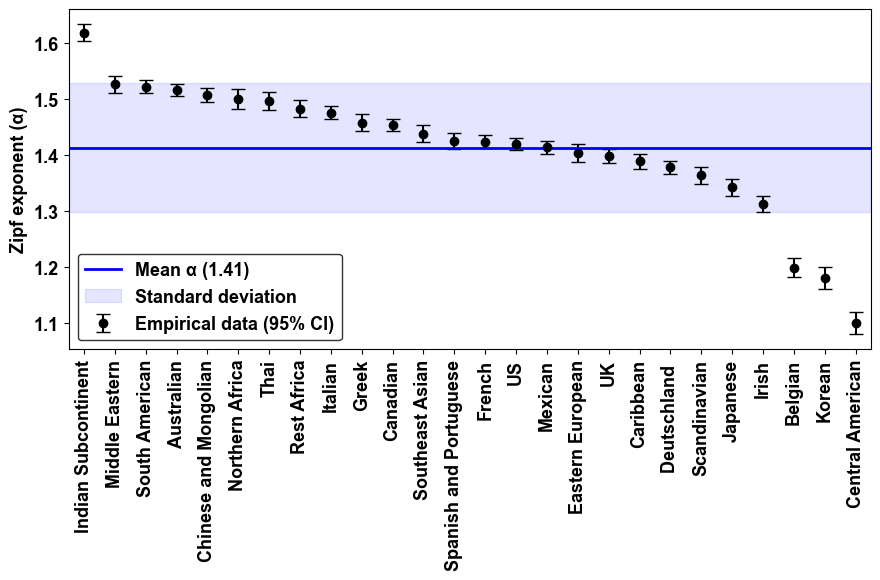


=== Zipf's Law α by Cuisine ===
               Cuisine  Alpha  Alpha_Low  Alpha_High  R_Squared
   Indian Subcontinent 1.6178     1.6033      1.6323     0.9499
        Middle Eastern 1.5254     1.5106      1.5402     0.9553
        South American 1.5212     1.5094      1.5330     0.9503
            Australian 1.5157     1.5045      1.5268     0.9605
 Chinese and Mongolian 1.5069     1.4945      1.5194     0.9528
       Northern Africa 1.4995     1.4822      1.5169     0.9614
                  Thai 1.4954     1.4790      1.5117     0.9479
           Rest Africa 1.4820     1.4668      1.4971     0.9531
               Italian 1.4750     1.4639      1.4861     0.9312
                 Greek 1.4568     1.4416      1.4719     0.9455
              Canadian 1.4523     1.4417      1.4629     0.9569
       Southeast Asian 1.4377     1.4221      1.4533     0.9537
Spanish and Portuguese 1.4247     1.4101      1.4392     0.9518
                French 1.4234     1.4118      1.4350     0.9487
       

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ==========================================
# REPRODUCIBILITY
# ==========================================
np.random.seed(42)

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13


def format_axes(ax):
    ax.grid(False)
    legend = ax.legend(frameon=True)
    if legend:
        legend.get_frame().set_edgecolor("black")


# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
df_ing = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv")

df_merged = pd.merge(
    df_ing,
    df_cuisine,
    left_on="recipe_no",
    right_on="Recipe_id"
)

# ------------------------------------------
# Filter cuisines with at least 50 recipes
# ------------------------------------------
recipe_counts = (
    df_merged.groupby("Cuisine")["recipe_no"]
    .nunique()
)

valid_cuisines = recipe_counts[recipe_counts >= 50].index

df_merged = df_merged[
    df_merged["Cuisine"].isin(valid_cuisines)
]


# ==========================================
# 2. CALCULATE ZIPF α PER CUISINE
# ==========================================
cuisines = df_merged["Cuisine"].unique()
results = []

print(f"Analyzing {len(cuisines)} cuisines...")

for cuisine in cuisines:

    subset = df_merged[df_merged["Cuisine"] == cuisine]

    counts = subset["ing_id"].value_counts()

    freqs = counts.values
    ranks = np.arange(1, len(freqs) + 1)

    # Proportional head trimming (5%)
    limit_head = max(0, int(0.05 * len(freqs)))

    mask = (ranks >= limit_head)

    if np.sum(mask) > 5:

        log_ranks = np.log(ranks[mask])
        log_freqs = np.log(freqs[mask])

        slope, intercept, r_value, p_value, std_err = linregress(
            log_ranks,
            log_freqs
        )

        alpha = -slope
        alpha_ci_95 = 1.96 * std_err

        results.append({
            "Cuisine": cuisine,
            "Alpha": alpha,
            "Alpha_Low": alpha - alpha_ci_95,
            "Alpha_High": alpha + alpha_ci_95,
            "R_Squared": r_value**2
        })

df_results = (
    pd.DataFrame(results)
    .sort_values("Alpha", ascending=False)
)

# ==========================================
# EXPORT RESULTS (replaces old Cell 2)
# ==========================================
df_results.to_csv(
    "zipf_alphas_by_cuisine.csv",
    index=False
)

print("\nZipf α values exported to:")
print("zipf_alphas_by_cuisine.csv")


# ==========================================
# 3. GENERATE PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(9, 6))

x_positions = np.arange(len(df_results))

y_errs = [
    df_results["Alpha"] - df_results["Alpha_Low"],
    df_results["Alpha_High"] - df_results["Alpha"]
]

# Empirical data
ax.errorbar(
    x_positions,
    df_results["Alpha"],
    yerr=y_errs,
    fmt="o",
    capsize=5,
    color="black",
    label="Empirical data (95% CI)"
)

# Mean α
mean_alpha = df_results["Alpha"].mean()
std_alpha = df_results["Alpha"].std()

# Mean line
ax.axhline(
    mean_alpha,
    color="blue",
    linestyle="-",
    linewidth=2,
    label=f"Mean α ({mean_alpha:.2f})"
)

# Full-width standard deviation band
x_band = np.concatenate(
    ([x_positions[0] - 0.5],
     x_positions,
     [x_positions[-1] + 0.5])
)

lower_band = np.repeat(
    mean_alpha - std_alpha,
    len(x_band)
)

upper_band = np.repeat(
    mean_alpha + std_alpha,
    len(x_band)
)

ax.fill_between(
    x_band,
    lower_band,
    upper_band,
    color="blue",
    alpha=0.1,
    label="Standard deviation"
)

# Labels
ax.set_ylabel("Zipf exponent (α)", fontweight="bold")

ax.set_xticks(x_positions)
ax.set_xticklabels(
    df_results["Cuisine"],
    rotation=90
)

ax.margins(x=0)

format_axes(ax)

plt.tight_layout()

# Save figures
plt.savefig(
    "cuisine_zipf_alpha_universality.png",
    dpi=300
)

plt.savefig(
    "cuisine_zipf_alpha_universality.tif",
    dpi=300
)

plt.show()
# ==========================================
# RESULTS TABLE
# ==========================================
df_results_display = df_results.copy()

df_results_display["Alpha"] = df_results_display["Alpha"].round(4)
df_results_display["Alpha_Low"] = df_results_display["Alpha_Low"].round(4)
df_results_display["Alpha_High"] = df_results_display["Alpha_High"].round(4)
df_results_display["R_Squared"] = df_results_display["R_Squared"].round(4)

print("\n=== Zipf's Law α by Cuisine ===")
print(df_results_display.to_string(index=False))

### Zipf Exponent Estimation Across Cuisines

This analysis estimates the Zipf exponent (α) for ingredient usage frequencies within each cuisine. Ingredient frequencies are ranked and fitted using linear regression in log–log space. Only cuisines containing at least 50 unique recipes are included to ensure statistical reliability. A 95% confidence interval is calculated for each estimated exponent, and the results are exported for further analysis.

Calculating Heaps β for 26 cuisines...

=== Heaps' Law β by Cuisine ===
               Cuisine   Beta  Lower_CI_95  Upper_CI_95  R_Squared  Num_Recipes
      Central American 0.6331       0.6223       0.6438     0.9917          455
                Korean 0.6173       0.6101       0.6244     0.9957          668
               Belgian 0.5982       0.5917       0.6047     0.9967         1060
                 Irish 0.5769       0.5718       0.5820     0.9978         2529
              Japanese 0.5554       0.5498       0.5611     0.9973         2040
             Caribbean 0.5553       0.5506       0.5601     0.9981         3023
               Mexican 0.5528       0.5507       0.5549     0.9996        14447
          Scandinavian 0.5522       0.5458       0.5586     0.9965         2811
                    UK 0.5492       0.5442       0.5543     0.9977         4396
          Deutschland  0.5488       0.5455       0.5521     0.9990         4321
                French 0.5459       0.5421      

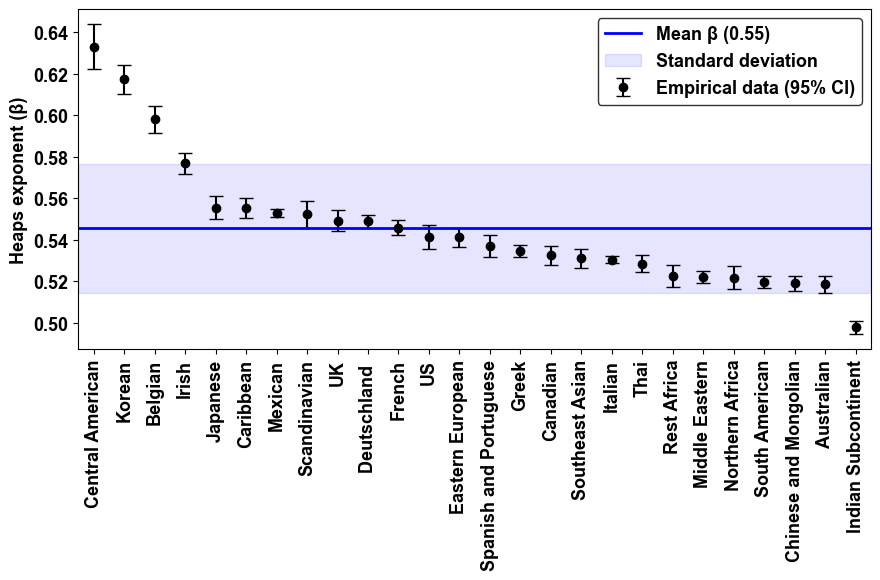

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

# Load Data
df_ing = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv")
df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')
recipe_counts = (
    df_merged.groupby('Cuisine')['recipe_no']
    .nunique()
)

valid_cuisines = recipe_counts[
    recipe_counts >= 50
].index

df_merged = df_merged[
    df_merged['Cuisine'].isin(valid_cuisines)
]

# Get Cuisines
cuisines = df_merged['Cuisine'].unique()
results = []

print(f"Calculating Heaps β for {len(cuisines)} cuisines...")

for cuisine in cuisines:

    subset = df_merged[
        df_merged['Cuisine'] == cuisine
    ]

    recipes = (
        subset
        .groupby('recipe_no')['ing_id']
        .apply(set)
        .tolist()
    )

    betas = []
    r_squared_values = []
    std_errors = []

    for seed in [42, 43, 44]:

        np.random.seed(seed)

        shuffled_recipes = np.random.permutation(
            np.array(recipes, dtype=object)
        )

        unique_ingredients = set()

        x_n = []
        y_v = []

        total_tokens = 0

        sample_rate = max(
            1,
            len(shuffled_recipes) // 100
        )

        for i, recipe in enumerate(shuffled_recipes):

            unique_ingredients.update(recipe)

            total_tokens += len(recipe)

            if (
                (i + 1) % sample_rate == 0
                or
                (i + 1) == len(shuffled_recipes)
            ):
                x_n.append(total_tokens)
                y_v.append(len(unique_ingredients))

        if len(x_n) > 5:

            log_n = np.log(np.array(x_n))
            log_v = np.log(np.array(y_v))

            slope, intercept, r_value, p_value, std_err = linregress(
                log_n,
                log_v
            )

            betas.append(slope)
            r_squared_values.append(r_value**2)
            std_errors.append(std_err)

    if len(betas) > 0:

        beta_mean = np.mean(betas)

        # Use regression uncertainty (same interpretation as original code)
        mean_std_err = np.mean(std_errors)
        beta_ci_95 = 1.96 * mean_std_err

        mean_r2 = np.mean(r_squared_values)

        results.append({
            'Cuisine': cuisine,
            'Beta': beta_mean,
            'Beta_Low': beta_mean - beta_ci_95,
            'Beta_High': beta_mean + beta_ci_95,
            'R_Squared': mean_r2,
            'Num_Recipes': len(recipes)
        })

df_results = pd.DataFrame(results).sort_values(
    'Beta',
    ascending=False
)

# ==========================================
# RESULTS TABLE
# ==========================================
df_results_display = df_results.copy()

for col in ['Beta', 'Beta_Low', 'Beta_High', 'R_Squared']:
    df_results_display[col] = (
        df_results_display[col].round(4)
    )

df_results_display = df_results_display.rename(columns={
    'Beta_Low': 'Lower_CI_95',
    'Beta_High': 'Upper_CI_95'
})

print("\n=== Heaps' Law β by Cuisine ===")

print(
    df_results_display[
        [
            'Cuisine',
            'Beta',
            'Lower_CI_95',
            'Upper_CI_95',
            'R_Squared',
            'Num_Recipes'
        ]
    ].to_string(index=False)
)

# ==========================================
# EXPORT RESULTS
# ==========================================
df_results_display.to_csv(
    "heaps_betas_by_cuisine.csv",
    index=False
)

print(
    "\nResults exported to: "
    "heaps_betas_by_cuisine.csv"
)

# ==========================================
# Plot
# ==========================================
fig, ax = plt.subplots(figsize=(9,6))

x_positions = np.arange(len(df_results))

y_errs = [
    df_results['Beta'] - df_results['Beta_Low'],
    df_results['Beta_High'] - df_results['Beta']
]

# Empirical points
ax.errorbar(
    x_positions,
    df_results['Beta'],
    yerr=y_errs,
    fmt='o',
    capsize=5,
    color='black',
    label='Empirical data (95% CI)'
)

# Mean β
mean_beta = df_results['Beta'].mean()
std_beta = df_results['Beta'].std()

# Mean line
ax.axhline(
    mean_beta,
    color='blue',
    linestyle='-',
    linewidth=2,
    label=f'Mean β ({mean_beta:.2f})'
)

# Full-width standard deviation band
x_band = np.concatenate(([x_positions[0]-0.5], x_positions, [x_positions[-1]+0.5]))

lower_band = np.repeat(mean_beta - std_beta, len(x_band))
upper_band = np.repeat(mean_beta + std_beta, len(x_band))

ax.fill_between(
    x_band,
    lower_band,
    upper_band,
    color='blue',
    alpha=0.1,
    label='Standard deviation'
)

# Axis label
ax.set_ylabel("Heaps exponent (β)", fontweight="bold")

ax.set_xticks(x_positions)
ax.set_xticklabels(df_results['Cuisine'], rotation=90)

# Remove margins so band touches edges
ax.margins(x=0)

ax.grid(False)

legend = ax.legend(frameon=True)

if legend:
    legend.get_frame().set_edgecolor("black")

plt.tight_layout()

plt.savefig("heaps_beta_by_cuisine.png", dpi=300)
plt.savefig("heaps_beta_by_cuisine.tif", dpi=300)

plt.show()

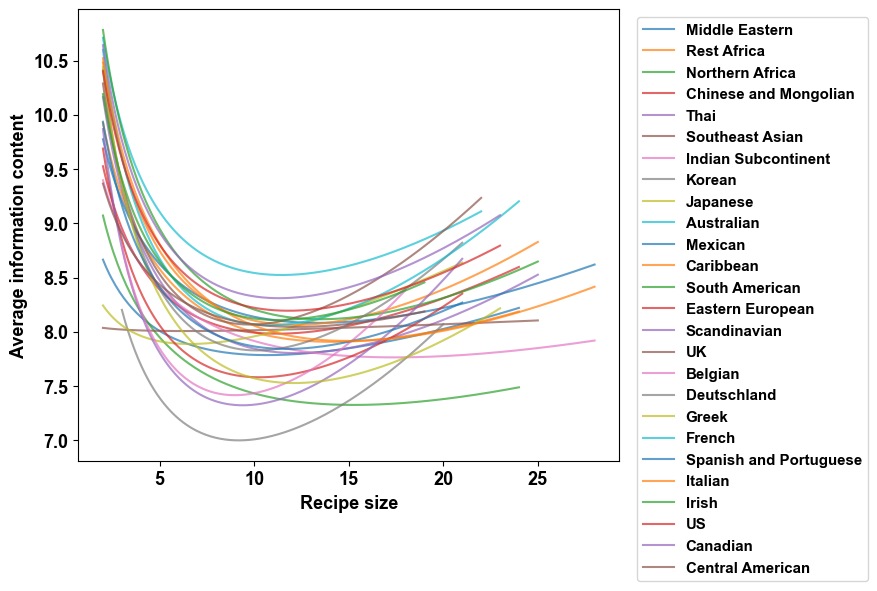


=== Menzerath–Altmann Parameters by Cuisine ===
               Cuisine         a         b         c    a_err    b_err    c_err
        Middle Eastern  9.226990 -0.124251 -0.011638 0.207670 0.018876 0.001941
           Rest Africa 11.121521 -0.206779 -0.014613 0.150252 0.011689 0.001233
       Northern Africa 10.058903 -0.183715 -0.012028 0.225384 0.019339 0.002038
 Chinese and Mongolian 10.536278 -0.195846 -0.017460 0.235298 0.019012 0.001976
                  Thai 11.731432 -0.270808 -0.022103 0.212478 0.015342 0.001567
       Southeast Asian  8.059111 -0.007731 -0.001219 0.259158 0.026219 0.002637
   Indian Subcontinent 10.243655 -0.149204 -0.008563 0.211543 0.016130 0.001497
                Korean 10.797615 -0.356305 -0.038814 0.630772 0.050040 0.005295
              Japanese  8.532354 -0.088665 -0.013438 0.231539 0.024772 0.002858
            Australian 12.182375 -0.248321 -0.021679 0.222094 0.016653 0.001874
               Mexican 10.787022 -0.181293 -0.013566 0.305882 0.022063 

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

# ---- Load & Merge Data ----
df_ing = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv")
df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

# ---- Minimum recipes per cuisine ----
MIN_RECIPES = 50

cuisines = df_merged['Cuisine'].unique()
results_ma = []

def ma_model(x, A, b, c):
    return A * (x**b) * np.exp(-c * x)

fig, ax = plt.subplots(figsize=(9, 6))

for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine].copy()

    # Skip cuisines with too few recipes for stable fitting
    n_recipes = subset['recipe_no'].nunique()
    if n_recipes < MIN_RECIPES:
        print(f"  Skipping {cuisine}: only {n_recipes} recipes (< {MIN_RECIPES})")
        continue

    # Local Information Content
    ing_counts = subset['ing_id'].value_counts()
    N = len(subset)
    probs = ing_counts / N
    subset['ic'] = -np.log2(subset['ing_id'].map(probs))

    # Mean IC per recipe
    recipe_stats = subset.groupby('recipe_no').agg(
        length=('ing_id', 'count'),
        mean_ic=('ic', 'mean')
    )

    # Mean-field averaging over recipe lengths
    ma_data = recipe_stats.groupby('length')['mean_ic'].mean().reset_index()

    # Keep only lengths with >= 5 recipes for stability
    counts = recipe_stats['length'].value_counts()
    valid_lengths = counts[counts >= 5].index
    ma_data = ma_data[ma_data['length'].isin(valid_lengths)].sort_values('length')

    if len(ma_data) <= 5:
        print(f"  Skipping {cuisine}: insufficient length bins after filtering")
        continue

    x_data = ma_data['length'].values
    y_data = ma_data['mean_ic'].values

    try:
        # Better initial guess: start near data, positive decay
        p0 = [y_data[0], -0.2, 0.01]

        popt, pcov = curve_fit(
            ma_model,
            x_data,
            y_data,
            p0=p0,
            maxfev=10000
        )
        perr = np.sqrt(np.diag(pcov))  # standard errors on each parameter

        results_ma.append({
            'Cuisine': cuisine,
            'a': popt[0], 'b': popt[1], 'c': popt[2],
            'a_err': perr[0], 'b_err': perr[1], 'c_err': perr[2]
        })

        x_line = np.linspace(min(x_data), max(x_data), 200)
        ax.plot(x_line, ma_model(x_line, *popt), alpha=0.7, label=cuisine)

    except Exception as e:
        print(f"  Fit failed for {cuisine}: {e}")

ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")
ax.grid(False)

legend = ax.legend(
    frameon=True,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize='small'
)

plt.tight_layout()
plt.savefig("menzerath_altmann_cuisines.png", dpi=300)
plt.savefig("menzerath_altmann_cuisines.tif", dpi=300)
plt.show()

# ---- Parameter Table ----
df_params = pd.DataFrame(results_ma)
print("\n=== Menzerath–Altmann Parameters by Cuisine ===")
print(df_params.to_string(index=False))

df_params.to_csv("menzerath_altmann_parameters_by_cuisine.csv", index=False)
print("\nParameters exported to: menzerath_altmann_parameters_by_cuisine.csv")

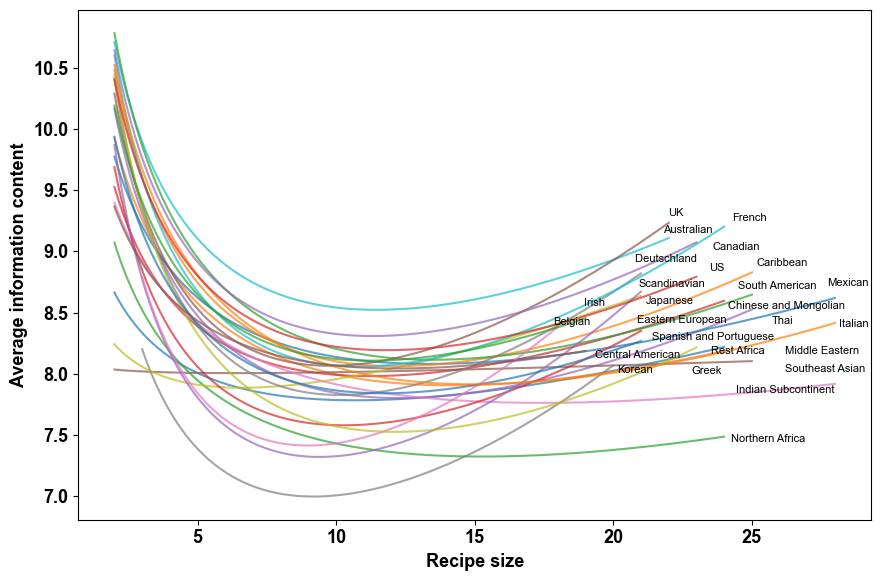

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from adjustText import adjust_text

# ---- Global Plot Style ----
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["font.size"] = 13

# ---- Load & Merge Data ----
df_ing = pd.read_csv("Datasets/RecipeID_Ing_ID.csv")
df_cuisine = pd.read_csv("Datasets/RecipeDB_RecipeID_Cuisine.csv")
df_merged = pd.merge(df_ing, df_cuisine, left_on='recipe_no', right_on='Recipe_id')

# ---- Minimum recipes per cuisine ----
MIN_RECIPES = 50

cuisines = df_merged['Cuisine'].unique()

def ma_model(x, A, b, c):
    return A * (x**b) * np.exp(-c * x)

fig, ax = plt.subplots(figsize=(9, 6))
texts = []  # collect label objects for adjustText

for cuisine in cuisines:
    subset = df_merged[df_merged['Cuisine'] == cuisine].copy()

    n_recipes = subset['recipe_no'].nunique()
    if n_recipes < MIN_RECIPES:
        print(f"  Skipping {cuisine}: only {n_recipes} recipes (< {MIN_RECIPES})")
        continue

    ing_counts = subset['ing_id'].value_counts()
    N = len(subset)
    probs = ing_counts / N
    subset['ic'] = -np.log2(subset['ing_id'].map(probs))

    recipe_stats = subset.groupby('recipe_no').agg(
        length=('ing_id', 'count'),
        mean_ic=('ic', 'mean')
    )

    ma_data = recipe_stats.groupby('length')['mean_ic'].mean().reset_index()

    counts = recipe_stats['length'].value_counts()
    valid_lengths = counts[counts >= 5].index
    ma_data = ma_data[ma_data['length'].isin(valid_lengths)].sort_values('length')

    if len(ma_data) <= 5:
        print(f"  Skipping {cuisine}: insufficient length bins after filtering")
        continue

    x_data = ma_data['length'].values
    y_data = ma_data['mean_ic'].values

    try:
        p0 = [y_data[0], -0.2, 0.01]

        popt, pcov = curve_fit(
            ma_model,
            x_data,
            y_data,
            p0=p0,
            maxfev=10000
        )

        x_line = np.linspace(min(x_data), max(x_data), 200)
        y_line = ma_model(x_line, *popt)

        ax.plot(x_line, y_line, alpha=0.7)

        # Collect label — adjustText will resolve overlaps after the loop
        texts.append(ax.text(
            x_line[-1], y_line[-1],
            cuisine,
            fontsize=8,
            fontweight='normal',
            va='center'
        ))

    except Exception as e:
        print(f"  Fit failed for {cuisine}: {e}")

# Automatically nudge overlapping labels apart — no hardcoded shifts needed
adjust_text(texts, ax=ax)

ax.set_xlabel("Recipe size", fontweight="bold")
ax.set_ylabel("Average information content", fontweight="bold")
ax.grid(False)

plt.tight_layout()
plt.savefig("menzerath_altmann_cuisines_labeled.png", dpi=300)
plt.savefig("menzerath_altmann_cuisines_labeled.tif", dpi=300)
plt.show()

## Cell 5 — Menzerath–Altmann Law by Cuisine

Fits a **Menzerath–Altmann (MA) model** to each cuisine independently, asking whether
longer recipes tend to use lower-information (more predictable) ingredients on average.

### Model

$$\langle IC \rangle(L) = A \cdot L^{b} \cdot e^{-cL}$$

| Parameter | Role |
|-----------|------|
| $A$ | amplitude (overall IC scale) |
| $b$ | power-law growth at short lengths |
| $c$ | exponential decay at long lengths |

The interplay of $b$ and $c$ determines whether IC peaks early and falls off
(classic MA behaviour) or rises monotonically within the observed range.

### Pipeline

1. **Merge** ingredient and cuisine tables on `recipe_no` / `Recipe_id`.
2. **Local IC** — ingredient probabilities are computed *within* each cuisine, so
   information content is relative to that cuisine's own lexicon.
3. **Mean-field average** — for each recipe length $L$, average $\langle IC \rangle$
   across all recipes of that length.
4. **Stability filter** — lengths represented by fewer than 5 recipes are dropped;
   cuisines with fewer than 50 recipes are skipped entirely.
5. **Curve fit** — `scipy.optimize.curve_fit` with initial guess
   $[y_0,\ -0.2,\ 0.01]$ anchored to the first data point.
6. **Uncertainty** — `pcov` diagonal gives standard errors on $A$, $b$, $c$;
   stored alongside point estimates in the exported CSV.

### Outputs

| File | Contents |
|------|----------|
| `menzerath_altmann_cuisines.png / .tif` | MA curves, one colour per cuisine, external legend (Cell 5a) |
| `menzerath_altmann_cuisines_labeled.png / .tif` | Same curves, inline cuisine labels de-overlapped by `adjustText` (Cell 5b) |
| `menzerath_altmann_parameters_by_cuisine.csv` | $A, b, c$ and their standard errors for every successfully fitted cuisine |

### Notes

- Fits that fail (singular covariance, convergence timeout, etc.) print a warning
  with the cuisine name and the exact `scipy` error — they are excluded from the
  plot and CSV rather than silently dropped.
- Cell 5a and 5b run the same fitting loop; 5b replaces the external legend with
  `adjustText` inline labels and omits the parameter export (already done in 5a).
- Parameter uncertainties in the CSV allow downstream filtering of poorly
  constrained fits (e.g. discard rows where `a_err / a > 0.5`).